# Étape 4 : Analyse et Optimisation des Performances

In [1]:

import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

import sys

project_root = r"C:\Users\j-a-b\Documents\OpenClassrooms\Projet 5 PMVL Asset"
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from app.schemas import PMVLFeatures
from app.main import run_model_prediction

%matplotlib inline
sns.set_theme(style="whitegrid")


c:\Users\j-a-b\Documents\OpenClassrooms\Projet 5 PMVL Asset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Analyse de la baseline (logs de production)
On commence par lire le fichier de logs `production_logs.jsonl` pour avoir l'état actuel des performances (latence globale).

--- BASELINE DE PRODUCTION ---
Total des requêtes: 2
Taux d'erreur: 0.00%

Latence globale (API + Modèle) :
  Moyenne: 11.54 ms
  Médiane (p50): 11.54 ms
  p90: 12.07 ms
  p95: 12.13 ms
  Max: 12.20 ms


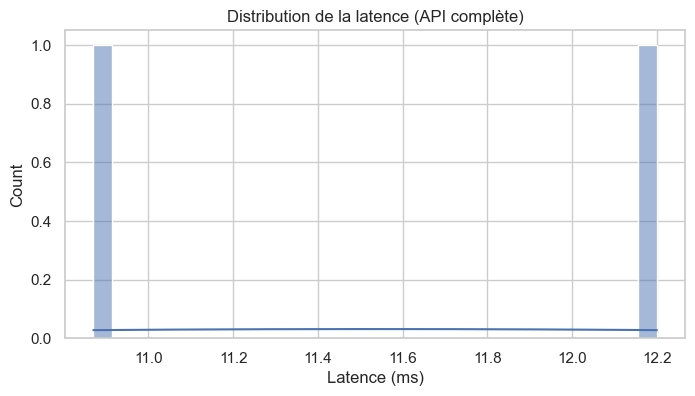

In [2]:

# 1. Analyse des logs de production existants dans "C:\Users\j-a-b\Documents\OpenClassrooms\Projet 5 PMVL Asset\logs"

logs_path = Path(project_root) / "logs" / "production_logs.jsonl"

logs = []
if logs_path.exists():
    with open(logs_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                logs.append(json.loads(line))

df_logs = pd.DataFrame(logs)

if not df_logs.empty:
    print("--- BASELINE DE PRODUCTION ---")
    print(f"Total des requêtes: {len(df_logs)}")
    print(f"Taux d'erreur: {(df_logs['status_code'] >= 400).mean() * 100:.2f}%")

    if "latency_ms" in df_logs.columns:
        print(f"\nLatence globale (API + Modèle) :")
        print(f"  Moyenne: {df_logs['latency_ms'].mean():.2f} ms")
        print(f"  Médiane (p50): {df_logs['latency_ms'].median():.2f} ms")
        print(f"  p90: {df_logs['latency_ms'].quantile(0.90):.2f} ms")
        print(f"  p95: {df_logs['latency_ms'].quantile(0.95):.2f} ms")
        print(f"  Max: {df_logs['latency_ms'].max():.2f} ms")

        # Petit plot pour visualiser
        plt.figure(figsize=(8, 4))
        sns.histplot(df_logs['latency_ms'], bins=30, kde=True)
        plt.title('Distribution de la latence (API complète)')
        plt.xlabel('Latence (ms)')
        plt.show()
else:
    print("Aucun log de production trouvé. Lancez d'abord quelques requêtes API.")


## 2. Micro-benchmark et Profiling
On isole la fonction `run_model_prediction` (sans FastAPI ni réseau) pour voir le temps pur de préparation des données et d'inférence.

In [3]:
import os
import sys
import time

project_root = r"C:\Users\j-a-b\Documents\OpenClassrooms\Projet 5 PMVL Asset"
model_path = r"C:\Users\j-a-b\Documents\OpenClassrooms\Projet 5 PMVL Asset\models\pmvl_catboost_final.cbm"
features_path = r"C:\Users\j-a-b\Documents\OpenClassrooms\Projet 5 PMVL Asset\models\pmvl_feature_columns.txt"

if project_root not in sys.path:
    sys.path.insert(0, project_root)

os.environ["MODEL_PATH"] = model_path
os.environ["FEATURES_PATH"] = features_path

from app.schemas import PMVLFeatures
from app.main import run_model_prediction
import os
import sys
import time

sample_input = {
    "holding_date": "2026-03-01",
    "pmvl_estim": 1500.0,
    "quantity": 100.0,
    "purch_val_clean": 45000.0,
    "quote": 510.0,
    "vnc_agrege_dirty": 49000.0,
    "entite": "ENTITE_TEST",
    "isin": "FR0000000001",
    "orig_name": "Asset Name Test",
    "ticker": "TICKER_TEST",
    "ref_unik_asset": "REF_12345",
    "fund_code": "FUND_001",
    "col_3a": "3A_TEST",
    "canton": "CANTON_TEST",
    "cic": "CIC_TEST",
    "groupe": "GROUPE_TEST",
    "ptf_name": "PTF_TEST"
}

features = PMVLFeatures(**sample_input)

project_root = r"C:\Users\j-a-b\Documents\OpenClassrooms\Projet 5 PMVL Asset"
model_path = r"C:\Users\j-a-b\Documents\OpenClassrooms\Projet 5 PMVL Asset\models\pmvl_catboost_final.cbm"
features_path = r"C:\Users\j-a-b\Documents\OpenClassrooms\Projet 5 PMVL Asset\models\pmvl_feature_columns.txt"

if project_root not in sys.path:
    sys.path.insert(0, project_root)

os.environ["MODEL_PATH"] = model_path
os.environ["FEATURES_PATH"] = features_path


sample_input = {
    "holding_date": "2026-03-01",
    "pmvl_estim": 1500.0,
    "quantity": 100.0,
    "purch_val_clean": 45000.0,
    "quote": 510.0,
    "vnc_agrege_dirty": 49000.0,
    "entite": "ENTITE_TEST",
    "isin": "FR0000000001",
    "orig_name": "Asset Name Test",
    "ticker": "TICKER_TEST",
    "ref_unik_asset": "REF_12345",
    "fund_code": "FUND_001",
    "col_3a": "3A_TEST",
    "canton": "CANTON_TEST",
    "cic": "CIC_TEST",
    "groupe": "GROUPE_TEST",
    "ptf_name": "PTF_TEST"
}

features = PMVLFeatures(**sample_input)

_ = run_model_prediction(features)

print("--- MICRO-BENCHMARK DU MODÈLE (100 itérations) ---")
latencies = []

for _ in range(100):
    start = time.perf_counter()
    _ = run_model_prediction(features)
    end = time.perf_counter()
    latencies.append((end - start) * 1000)

print("Temps d'inférence pur (fonction run_model_prediction):")
print(f"  Moyenne: {sum(latencies)/len(latencies):.2f} ms")
print(f"  Min: {min(latencies):.2f} ms")
print(f"  Max: {max(latencies):.2f} ms")

print("--- MICRO-BENCHMARK DU MODÈLE (100 itérations) ---")
latencies = []

for _ in range(100):
    start = time.perf_counter()
    _ = run_model_prediction(features)
    end = time.perf_counter()
    latencies.append((end - start) * 1000)

print("Temps d'inférence pur (fonction run_model_prediction):")
print(f"  Moyenne: {sum(latencies)/len(latencies):.2f} ms")
print(f"  Min: {min(latencies):.2f} ms")
print(f"  Max: {max(latencies):.2f} ms")

Chargement du modèle CatBoost en mémoire...
Modèle chargé avec succès !
--- MICRO-BENCHMARK DU MODÈLE (100 itérations) ---
Temps d'inférence pur (fonction run_model_prediction):
  Moyenne: 11.52 ms
  Min: 7.31 ms
  Max: 52.55 ms
--- MICRO-BENCHMARK DU MODÈLE (100 itérations) ---
Temps d'inférence pur (fonction run_model_prediction):
  Moyenne: 15.47 ms
  Min: 7.38 ms
  Max: 54.40 ms
